# Assignment: Xarray Fundamentals with Atmospheric Radiation Data

In [1]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
import pooch
fname = pooch.retrieve(
    'http://ldeo.columbia.edu/~danielmw/CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc',
    known_hash=None,  downloader=pooch.HTTPDownloader(verify=False)
)
print(fname)

/home/awk2145/.cache/pooch/a379a4cf37bf10809e636b0809c1c88b-CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc


# 1) Opening data and examining metadata

### 1.1) Open the dataset and display its contents

In [3]:
ds = xr.open_dataset(fname)
ds

ERROR 1: PROJ: proj_create_from_database: Open of /opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj failed


<xarray.Dataset> Size: 737MB
Dimensions:                      (lon: 360, time: 203, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (time, lat, lon) float32 53MB ...
    toa_lw_all_mon               (time, lat, lon) float32 53MB ...
    toa_net_all_mon              (time, lat, lon) float32 53MB ...
    toa_sw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_lw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_net_clr_mon              (time, lat, lon) float32 53MB ...
    ...                           ...
    toa_cre_net_mon              (time, lat, lon) float32 53MB ...
    solar_mon                    (time, lat, lon) float32 53MB ...
    cldarea_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldpress_total_daynight_mon  (time, lat, lon) float32 53MB ...
    cldtemp_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldtau_total_day_mon         (time, lat, lon) float32 53MB ...
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

### 1.2) Print out the long_name attribute of each variable

In [4]:
# Print variable: long name for each variable. Format the output so that the start of the long name attributes are aligned.

In [5]:
for varname in ds.data_vars:
    long_name = ds[varname].attrs.get('long_name', 'No description available')
   
    print(f"{varname:28}: {long_name}")

toa_sw_all_mon              : Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
toa_lw_all_mon              : Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
toa_net_all_mon             : Top of The Atmosphere Net Flux, Monthly Means, All-Sky conditions
toa_sw_clr_mon              : Top of The Atmosphere Shortwave Flux, Monthly Means, Clear-Sky conditions
toa_lw_clr_mon              : Top of The Atmosphere Longwave Flux, Monthly Means, Clear-Sky conditions
toa_net_clr_mon             : Top of The Atmosphere Net Flux, Monthly Means, Clear-Sky conditions
toa_cre_sw_mon              : Top of The Atmosphere Cloud Radiative Effects Shortwave Flux, Monthly Means
toa_cre_lw_mon              : Top of The Atmosphere Cloud Radiative Effects Longwave Flux, Monthly Means
toa_cre_net_mon             : Top of The Atmosphere Cloud Radiative Effects Net Flux, Monthly Means
solar_mon                   : Incoming Solar Flux, Monthly Means
cldarea_total_daynig

# 2) Basic reductions, arithmetic, and plotting

### 2.1) Calculate the time-mean of the entire dataset

In [6]:
time_mean = ds.mean(dim='time')
time_mean

<xarray.Dataset> Size: 4MB
Dimensions:                      (lon: 360, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (lat, lon) float32 259kB 122.3 122.3 ... 104.4
    toa_lw_all_mon               (lat, lon) float32 259kB 141.1 141.1 ... 194.1
    toa_net_all_mon              (lat, lon) float32 259kB -91.29 ... -126.3
    toa_sw_clr_mon               (lat, lon) float32 259kB 119.9 119.9 ... 89.47
    toa_lw_clr_mon               (lat, lon) float32 259kB 140.2 140.2 ... 200.4
    toa_net_clr_mon              (lat, lon) float32 259kB -88.03 ... -117.6
    ...                           ...
    toa_cre_net_mon              (lat, lon) float32 259kB -3.253 ... -8.651
    solar_mon                    (lat, lon) float32 259kB 172.1 172.1 ... 172.3
    cldarea_total_daynight_mon   (lat, lon) float32 259kB 51.52 51.52 ... 78.93
    cldpress_total_daynight_mon  (lat, lon) float32 259kB 486.5 486.5 ... 766.9
    cldtemp_total_daynight_mon   (lat, lon) float32 259kB 225.2 225.2 ... 247.9
    cldtau_total_day_mon         (lat, lon) float32 259kB 4.158 4.158 ... 4.821

### 2.2) From this, make a 2D plot of the the time-mean Top of Atmosphere (TOA) Longwave, Shortwave, and Incoming Solar Radiation

In [7]:
# (Use “All-Sky” conditions)
# Note the sign conventions on each variable.
# WHICH OF TWO CODES BELOW IS CORRECT???

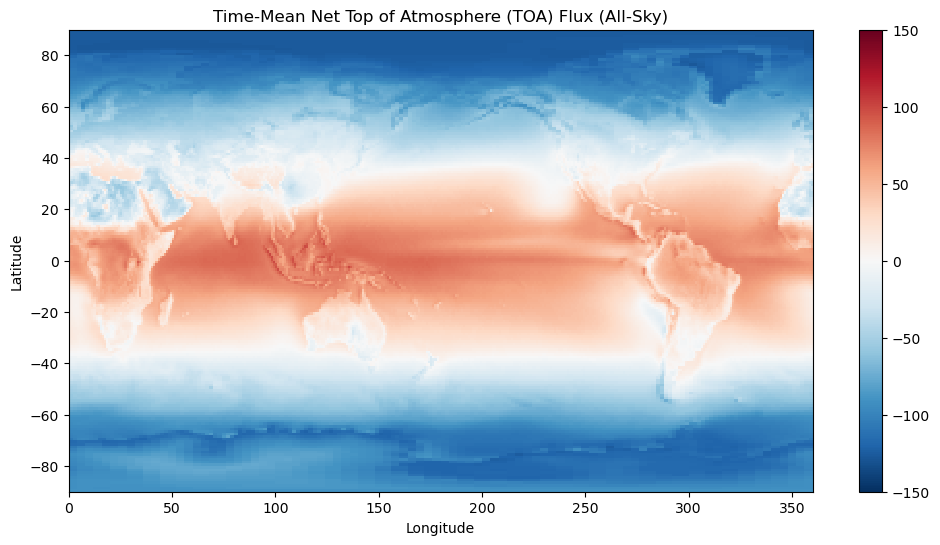

In [8]:
# Net Flux Plot
# Net = (Incoming) - (Reflected) - (Emitted)
net_flux = time_mean['solar_mon'] - time_mean['toa_sw_all_mon'] - time_mean['toa_lw_all_mon']

# create plot
plt.figure(figsize=(12, 6))
net_flux.plot(cmap='RdBu_r', vmin=-150, vmax=150)

# add labels, title
plt.title('Time-Mean Net Top of Atmosphere (TOA) Flux (All-Sky)')
plt.ylabel('Latitude')
plt.xlabel('Longitude')

plt.show()

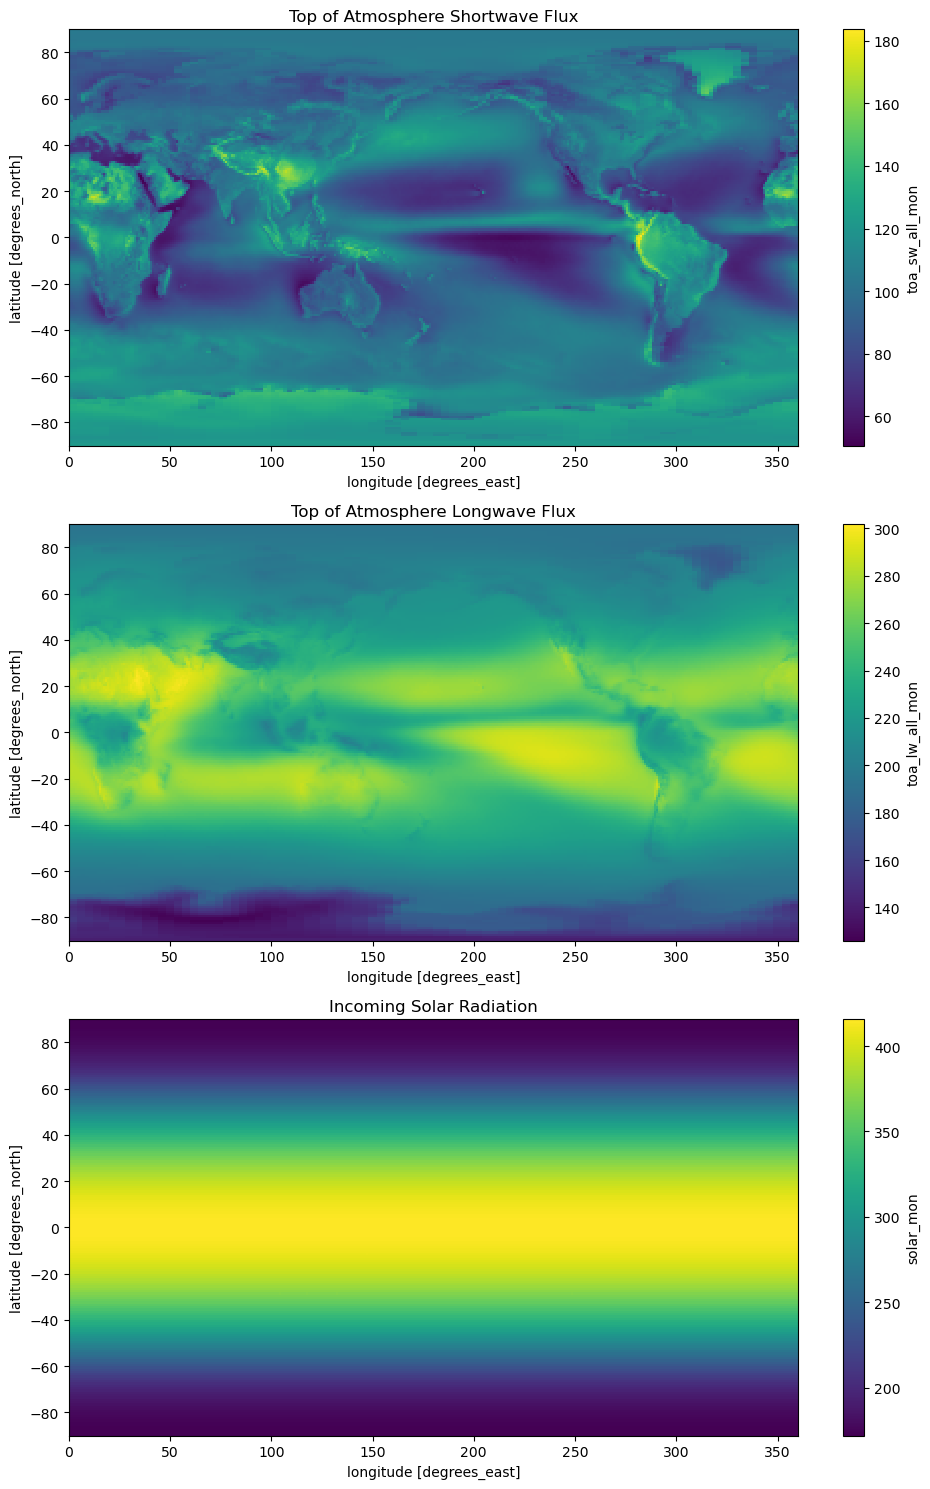

In [9]:
# creating one figure with 3 subplots - PROBABLY NEED TO DELETE!!!
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

time_mean['toa_sw_all_mon'].plot(ax=axes[0])
axes[0].set_title('Top of Atmosphere Shortwave Flux')

time_mean['toa_lw_all_mon'].plot(ax=axes[1])
axes[1].set_title('Top of Atmosphere Longwave Flux')

time_mean['solar_mon'].plot(ax=axes[2])
axes[2].set_title('Incoming Solar Radiation')

plt.tight_layout()
plt.show()

### 2.3) Add up the three variables above and verify (visually) that they are equivalent to the TOA net flux

In [10]:
# Pay attention to and think carefully about the sign conventions (positive or negative) for each variable in order for the variables to sum 
# to the right TOA net flux.
# Refer to the NASA figure at the top of the page to understand incoming and outgoing radiation.

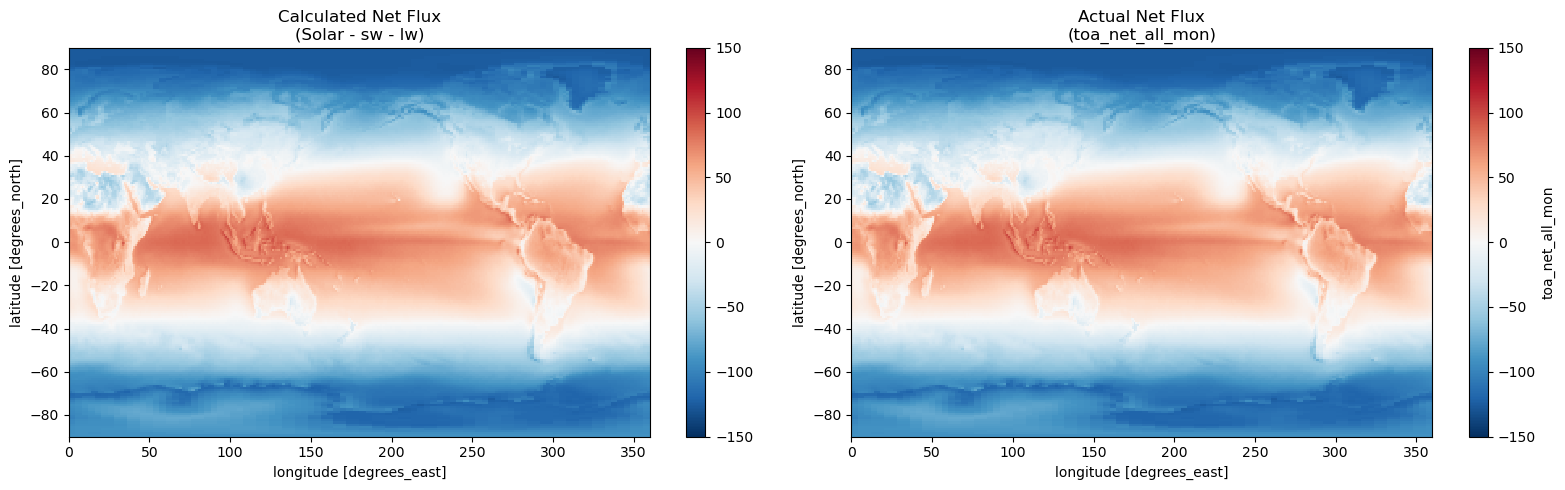

In [11]:
# incoming (Solar) - outgoing (shortwave + longwave)
calculated_net_flux = time_mean['solar_mon'] - time_mean['toa_sw_all_mon'] - time_mean['toa_lw_all_mon']

# get actual Net Flux variable from dataset for comparison
actual_net_flux = time_mean['toa_net_all_mon']

# plot side-by-side to visually verify 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

calculated_net_flux.plot(ax=ax1, cmap='RdBu_r', vmin=-150, vmax=150)
ax1.set_title('Calculated Net Flux\n(Solar - sw - lw)')

actual_net_flux.plot(ax=ax2, cmap='RdBu_r', vmin=-150, vmax=150)
ax2.set_title('Actual Net Flux\n(toa_net_all_mon)')

plt.tight_layout()
plt.show()

In [12]:
diff = calculated_net_flux - actual_net_flux
print(f"Max difference: {diff.max().values}")

Max difference: 0.013332366943359375


# 3) Mean and weighted mean

### 3.1) Calculate the global (unweighted) mean of TOA net radiation

In [13]:
# Since the Earth is approximately in radiative balance, the net TOA radiation should be zero. But taking the naive mean from this dataset, 
# you should find a number far from zero. Why?

# -> The answer is that each “pixel” or “grid point” of this dataset does not represent an equal area of Earth’s surface. 
# So naively taking the mean, i.e. giving equal weight to each point, gives the wrong answer.

# On a lat / lon grid, the relative area of each grid point is proportional to cos(lambda), ((lambda) is latitude)

In [35]:
tmean_weighted = time_mean['toa_net_all_mon'].weighted(weighted).mean(dim = ('lat', 'lon'))
tmean_weighted

<xarray.DataArray 'toa_net_all_mon' ()> Size: 4B
array(0.87808675, dtype=float32)

In [31]:
tmean_unweighted = time_mean['toa_net_all_mon'].mean(dim = ('lat', 'lon'))
tmean_unweighted

<xarray.DataArray 'toa_net_all_mon' ()> Size: 4B
array(-28.729012, dtype=float32)

### 3.2) Create a weight array proportional to cos(lambda)

In [39]:
# Think carefully a about radians vs. degrees
# To get from degrees to radians, you multiply by π / 180 or use np.deg2rad() function

In [38]:
# convert latitude degrees to radians
lat_radians = np.deg2rad(ds.lat)

# cosine of those radians, this creates weighting factor (1.0 at equator, 0.0 at poles)
weights = np.cos(lat_radians)
weights.name = "weights"
weights

<xarray.DataArray 'weights' (lat: 180)> Size: 720B
array([0.00872656, 0.02617699, 0.04361945, 0.06104851, 0.07845908,
       0.09584576, 0.11320324, 0.13052624, 0.14780948, 0.16504757,
       0.18223551, 0.19936794, 0.21643965, 0.23344542, 0.25037998,
       0.26723838, 0.28401536, 0.30070582, 0.3173047 , 0.33380693,
       0.35020736, 0.3665012 , 0.38268346, 0.3987491 , 0.4146933 ,
       0.43051115, 0.44619778, 0.4617486 , 0.47715878, 0.49242356,
       0.5075384 , 0.5224986 , 0.5372996 , 0.551937  , 0.56640625,
       0.58070296, 0.59482276, 0.6087614 , 0.62251467, 0.6360782 ,
       0.64944804, 0.66262007, 0.67559016, 0.68835455, 0.70090926,
       0.71325046, 0.72537434, 0.7372773 , 0.7489557 , 0.76040596,
       0.77162457, 0.78260815, 0.7933533 , 0.8038569 , 0.8141155 ,
       0.8241262 , 0.83388585, 0.8433914 , 0.85264015, 0.8616291 ,
       0.87035567, 0.87881714, 0.8870108 , 0.89493436, 0.90258527,
       0.9099613 , 0.9170601 , 0.9238795 , 0.9304176 , 0.9366722 ,
       0.9426415 , 0.94832367, 0.95371693, 0.95881975, 0.96363044,
       0.96814764, 0.9723699 , 0.976296  , 0.9799247 , 0.9832549 ,
       0.9862856 , 0.9890159 , 0.9914449 , 0.9935719 , 0.9953962 ,
       0.9969173 , 0.9981348 , 0.99904823, 0.99965733, 0.9999619 ,
       0.9999619 , 0.99965733, 0.99904823, 0.9981348 , 0.9969173 ,
       0.9953962 , 0.9935719 , 0.9914449 , 0.9890159 , 0.9862856 ,
       0.9832549 , 0.9799247 , 0.976296  , 0.9723699 , 0.96814764,
       0.96363044, 0.95881975, 0.95371693, 0.94832367, 0.9426415 ,
       0.9366722 , 0.9304176 , 0.9238795 , 0.9170601 , 0.9099613 ,
       0.90258527, 0.89493436, 0.8870108 , 0.87881714, 0.87035567,
       0.8616291 , 0.85264015, 0.8433914 , 0.83388585, 0.8241262 ,
       0.8141155 , 0.8038569 , 0.7933533 , 0.78260815, 0.77162457,
       0.76040596, 0.7489557 , 0.7372773 , 0.72537434, 0.71325046,
       0.70090926, 0.68835455, 0.67559016, 0.66262007, 0.64944804,
       0.6360782 , 0.62251467, 0.6087614 , 0.59482276, 0.58070296,
       0.56640625, 0.551937  , 0.5372996 , 0.5224986 , 0.5075384 ,
       0.49242356, 0.47715878, 0.4617486 , 0.44619778, 0.43051115,
       0.4146933 , 0.3987491 , 0.38268346, 0.3665012 , 0.35020736,
       0.33380693, 0.3173047 , 0.30070582, 0.28401536, 0.26723838,
       0.25037998, 0.23344542, 0.21643965, 0.19936794, 0.18223551,
       0.16504757, 0.14780948, 0.13052624, 0.11320324, 0.09584576,
       0.07845908, 0.06104851, 0.04361945, 0.02617699, 0.00872656],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Attributes:
    long_name:      latitude
    standard_name:  latitude
    units:          degrees_north
    valid_range:    [-90.  90.]

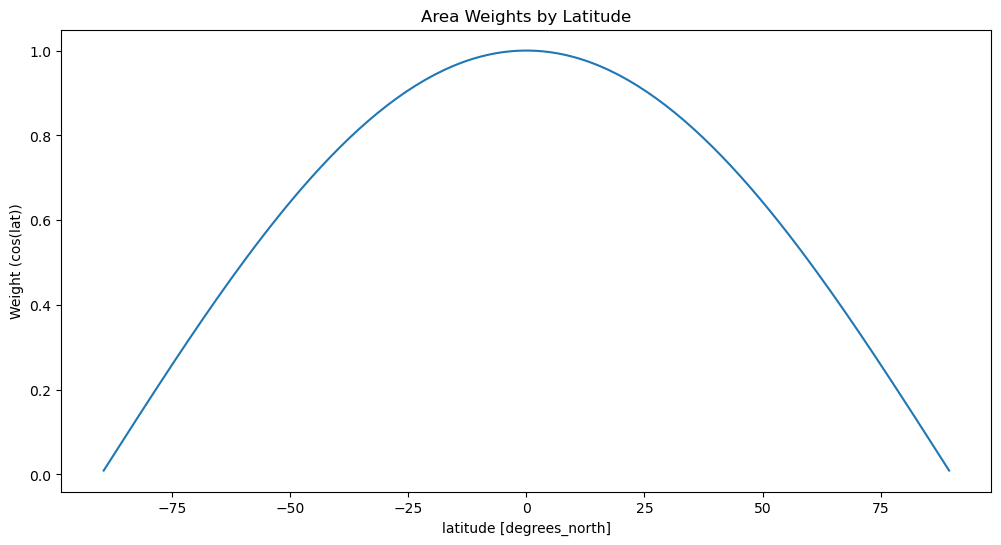

In [42]:
# check of distribtuion of weights
weights.plot()
plt.title('Area Weights by Latitude')
plt.ylabel('Weight (cos(lat))')
plt.show()

### 3.3) Redo your global mean TOA net radiation calculation with this weight factor

In [41]:
# Use xarray’s weighted array reductions to compute the weighted mean.
# This time around, you should have found something much closer to zero. 
# Ask a climate scientist what the net energy imbalance of Earth due to global warming is estimated to be. 
# Do you think our calculation is precise enough to detect this?

In [45]:
tmean_weighted = time_mean['toa_net_all_mon'].weighted(weights).mean(dim=('lat', 'lon'))
tmean_weighted

<xarray.DataArray 'toa_net_all_mon' ()> Size: 4B
array(0.87808675, dtype=float32)

In [46]:
# Answer: the calculation shows that the Earth is NOT in balance - there is some small positive energy left over, even after
# correcting for the Earth's spherical shape. This value of 0.8871 W/m2 seems to confirm a warming signal.

### 3.4) Now that you have a weight factor, verify that the TOA incoming solar, outgoing longwave, and outgoing shortwave approximately match up with infographic shown in the first cell of this assignment

In [47]:
solar_global = time_mean['solar_mon'].weighted(weights).mean()
solar_global
# 340.28
# graphic value: 340.4

<xarray.DataArray 'solar_mon' ()> Size: 4B
array(340.28354, dtype=float32)

In [48]:
lw_global = time_mean['toa_lw_all_mon'].weighted(weights).mean()
lw_global
# 240.27
# graphic value: 239.9

<xarray.DataArray 'toa_lw_all_mon' ()> Size: 4B
array(240.2667, dtype=float32)

In [49]:
sw_global = time_mean['toa_sw_all_mon'].weighted(weights).mean()
sw_global
# 99.14
# graphic value: 99.9

<xarray.DataArray 'toa_sw_all_mon' ()> Size: 4B
array(99.138596, dtype=float32)

# 4) Meridional Heat Transport Calculation

In [ ]:
# We can go beyond a weight factor and actually calculate the area of each pixel of the dataset, using the formula (not here)
# where degrees lambda and degrees phi are the spacing of the points in latitude and longitude (measured in radians). We can approximate Earth’s radius as R = 6,371km.

### 4.1) calculate the pixel area using this formula and create a 2D (lon, lat) DataArray for it

In [50]:
# (Xarray’s ones_like function can help you easily create and broadcast DataArrays.) Verify that the sum of all the pixels equals the Earth’s 
# true surface area as evaluated using the formula for the area of a sphere (yes, the Earth is not a sphere … it’s just a homework problem).

In [63]:
R = 6371 # Earth radius in km
d_lambda = np.deg2rad(1) # 1 degree spacing in radians - lat
d_phi = np.deg2rad(1)    # 1 degree spacing in radians - long

# 2D weighted - cos of latitude
# use xr.ones_like to make sure weights apply to entire grid
ones = xr.ones_like(ds.toa_net_all_mon.isel(time=0))
weighted_2d = np.cos(np.deg2rad(ds.lat)) * ones

# calculate area of each pixel
pixel_area = (R**2) * weighted_2d * d_lambda * d_phi

# 4. Verify the total surface area
total_area = pixel_area.sum()
sphere_area = 4 * np.pi * R**2

print(total_area.values)
print(sphere_area)

510070949.5545649
510064471.90978825


In [64]:
# total area = 510070949.55 km2
# sphere area = 510064471.91 km2

### 4.2) Calculate and plot the total amount of net radiation in each 1-degree latitude band

In [65]:
# Multiplying the pixel area (m2) from above with the radiative flux (W m-2) gives you the total amount of radiation absorbed in each pixel in W.
# Label with correct units.

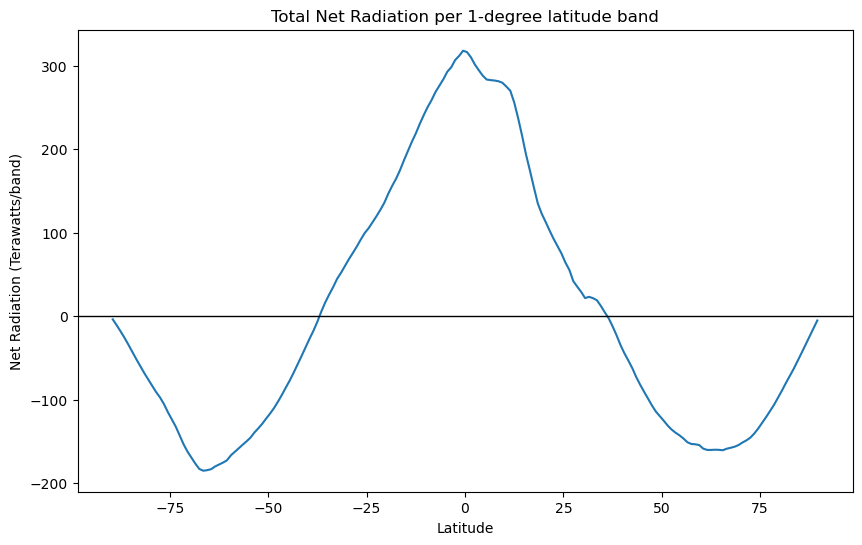

In [68]:
pixel_area_m2 = pixel_area * 1e6
total_watts_pixel = time_mean['toa_net_all_mon'] * pixel_area_m2

# sum across lon to get the total for each lat band
zonal_total_watts = total_watts_pixel.sum(dim='lon')

# convert to Terawatts (TW) for readable plot (1 TW = 10^12 Watts)
zonal_total_tw = zonal_total_watts / 1e12

plt.figure(figsize=(10, 6))
zonal_total_tw.plot()

plt.title('Total Net Radiation per 1-degree latitude band')
plt.xlabel('Latitude')
plt.ylabel('Net Radiation (Terawatts/band)')
plt.axhline(0, color='black', lw=1)
plt.show()

In [70]:
# large positive peak around the equator bc it has the most surface area and the most direct sunlight
# dips at poles bc they lose a lot of energy per square meter, total Terawatts drop off sharply as it reaches 90 

### 4.3) Plot the cumulative sum of the total amount of net radiation as a function of latitude

In [69]:
# Label with correct units. (Hint: check out xarray’s cumsum function.)
# This curve tells you how much energy must be transported meridionally by the ocean and atmosphere in order to account for 
# the radiative imbalance at the top of the atmosphere.
# You should get a curve that looks something like this: 
# https://journals.ametsoc.org/view/journals/clim/14/16/full-i1520-0442-14-16-3433-f07.gif (Figure from Trenberth & Caron, 2001)

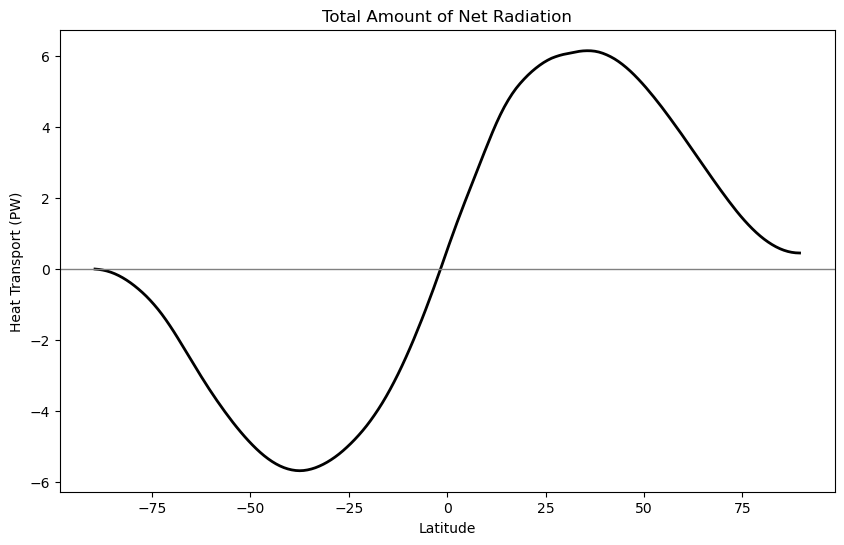

In [75]:
# cumulative sum of zonal total, by adding up energy starting from the south pole and moving north
total_transport_watts = zonal_total_watts.cumsum()

# convert to Petawatts for plot (1 PW = 1e15 W) - to match sample figure
total_transport_pw = total_transport_watts / 1e15

plt.figure(figsize=(10, 6))
total_transport_pw.plot(color='black', linewidth=2)

plt.title('Total Amount of Net Radiation')
plt.xlabel('Latitude')
plt.ylabel('Heat Transport (PW)')
plt.axhline(0, color='gray', linewidth=1)

In [79]:
# negative values in the southern hemisphere and positive values in the northern hemisphere 
# show that heat is flowing away from the equator toward both poles

# 5) Making Maps with Cartopy

In [ ]:
# DON"T DO 5.1!!!!

### 5.2) Antarctic Sea Ice

In [78]:
# Download this file and then use it to plot the concentration of Antarctic Sea Ice on Aug. 7, 2017. 
# Again, you will need to explore the file contents in order to determine the correct projection.

In [88]:
import xarray as xr
import pooch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
url = 'https://polarwatch.noaa.gov/erddap/files/nsidcCDRiceSQsh1day/2017/seaice_conc_daily_sh_f17_20170807_v03r01.nc'
fname = pooch.retrieve(url, known_hash='19b74e7e97f1c0786da0c674c4d5e4af0da5b32e2fe8c66a8f1a8a9a1241e73c')
ds_ice = xr.open_dataset(fname, drop_variables='melt_onset_day_seaice_conc_cdr')
print(ds_ice)

<xarray.Dataset> Size: 4MB
Dimensions:                     (time: 1, ygrid: 332, xgrid: 316)
Coordinates:
  * time                        (time) datetime64[ns] 8B 2017-08-07T12:00:00
  * ygrid                       (ygrid) float32 1kB 4.338e+06 ... -3.938e+06
  * xgrid                       (xgrid) float32 1kB -3.938e+06 ... 3.938e+06
    latitude                    (ygrid, xgrid) float64 839kB ...
    longitude                   (ygrid, xgrid) float64 839kB ...
Data variables:
    projection                  |S1 1B ...
    seaice_conc_cdr             (time, ygrid, xgrid) float32 420kB ...
    stdev_of_seaice_conc_cdr    (time, ygrid, xgrid) float32 420kB ...
    qa_of_seaice_conc_cdr       (time, ygrid, xgrid) float32 420kB ...
    goddard_merged_seaice_conc  (time, ygrid, xgrid) float32 420kB ...
    goddard_nt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
    goddard_bt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
Attributes: (12/70)
    references:             

In [81]:
# ygrid: 332, xgrid: 316)
# is a NetCDF grid (part of NOAA/NSIDC Climate Data Records) mapping sea ice in the Southern Hemisphere, 
# likely using a polar stereographic projection

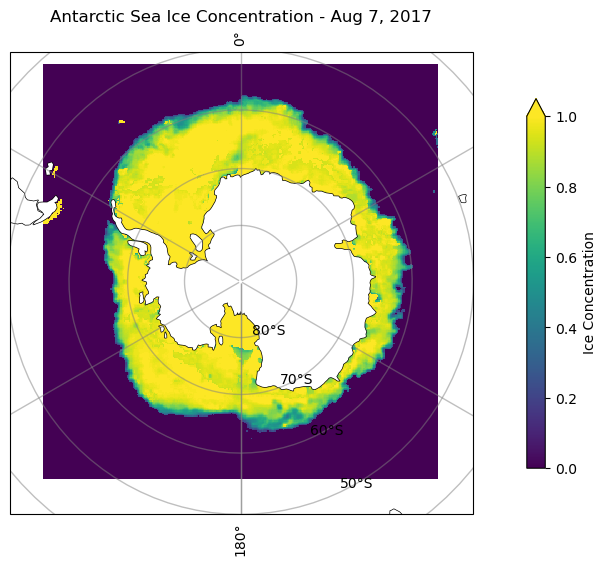

In [96]:
plt.figure(figsize=(14, 6))
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())

ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='-')
ax.coastlines(resolution='110m', color='black')
ax.add_feature(cfeature.LAND, facecolor='white', zorder=1.5)

ds_ice.seaice_conc_cdr.sel(time='2017-08-07').plot(
    ax=ax,
    vmax=1.0,
    transform=ccrs.SouthPolarStereo(), 
    cbar_kwargs={'shrink': 0.8, 'label': 'Ice Concentration'},
    zorder=1
)

plt.title('Antarctic Sea Ice Concentration - Aug 7, 2017')
plt.show()

### 5.3) Global USGS Earthquakes

In [98]:
#Reload the file we explored in homework 5 using pandas
# http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv
# and use the data to recreate this map.

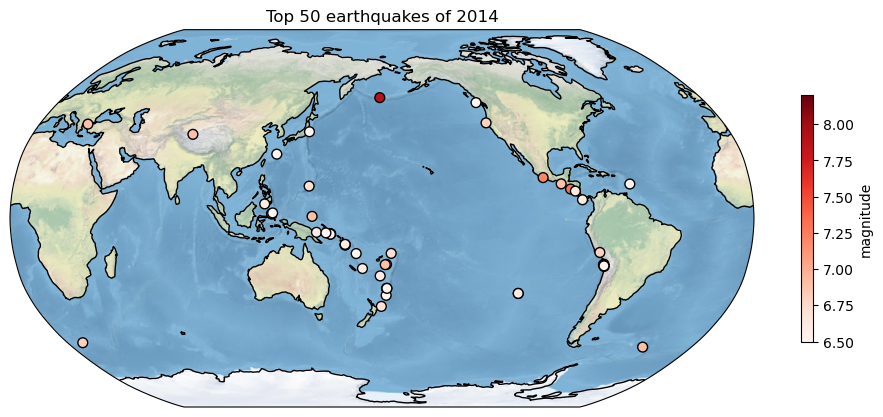

In [106]:
import pandas as pd

df = pd.read_csv('http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv')
top50 = df.sort_values('mag', ascending=False).head(50)

plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
ax.set_global()
ax.stock_img()
ax.coastlines()

sc = ax.scatter(top50['longitude'], top50['latitude'], 
                c=top50['mag'], 
                cmap='Reds', 
                edgecolor='black', 
                s=50,                # Size of the dots
                transform=ccrs.PlateCarree(), # Points are in lat/lon
                zorder=3)

plt.colorbar(sc, label='magnitude', shrink=0.4, pad=0.05)

plt.title('Top 50 earthquakes of 2014')
plt.show()